In [ ]:
import pandas as pd
import numpy as np

files = {
    2021:'Fenologi_2021_MODELLING.csv',
    2022:'Fenologi_2022_MODELLING.csv',
    2023:'Fenologi_2023_MODELLING.csv',
    2024:'Fenologi_2024_MODELLING.csv'
}

dfs = []

for year, file in files.items():

    temp = pd.read_csv(file)

    temp['Year'] = year

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
print(df['Year'].value_counts().sort_index())

(11571, 23)
Year
2021    1953
2022    1071
2023    6209
2024    2338
Name: count, dtype: int64


In [ ]:
sensor_cols = [
    'NDVI',
    'NDRE',
    'VV',
    'VH',
    'RVI'
]

df[sensor_cols] = (
    df[sensor_cols]
    .replace(-9999, np.nan)
)

In [ ]:
df['StartDate'] = pd.to_datetime(df['StartDate'])

df['Month'] = (
    df['StartDate']
    .dt.month
)

In [ ]:
df['S2_missing'] = (
    df['NDVI'].isna() |
    df['NDRE'].isna()
)

quality = (
    df.groupby(
        ['OBJECTID','Year']
    )['S2_missing']
    .mean()
    .reset_index()
)

quality.columns = [
    'OBJECTID',
    'Year',
    'Missing_S2'
]

In [ ]:
def classify_quality(x):

    if x <= 0.30:
        return 2

    elif x <= 0.50:
        return 1

    else:
        return 0

quality['S2_Quality'] = (
    quality['Missing_S2']
    .apply(classify_quality)
)

In [ ]:
df = df.merge(
    quality,
    on=['OBJECTID','Year'],
    how='left'
)

In [ ]:
phase_order = {
    'Flooding':1,
    'EarlyVeg':2,
    'Veg1':3,
    'Veg2':4,
    'Gen1':5,
    'Gen2':6,
    'Bare':7
}

df['phase_order'] = (
    df['Phase']
    .map(phase_order)
)

In [ ]:
df = (
    df.sort_values(
        [
            'OBJECTID',
            'Year',
            'phase_order'
        ]
    )
    .reset_index(drop=True)
)

In [ ]:
for col in [
    'VV',
    'VH',
    'RVI'
]:

    df[f'{col}_Lag1'] = (
        df.groupby(
            ['OBJECTID','Year']
        )[col]
        .shift(1)
    )

    df[f'{col}_Lag2'] = (
        df.groupby(
            ['OBJECTID','Year']
        )[col]
        .shift(2)
    )

    df[f'Delta_{col}'] = (
        df[col]
        -
        df[f'{col}_Lag1']
    )

In [ ]:
for col in [
    'NDVI',
    'NDRE'
]:

    df[f'{col}_Lag1'] = (
        df.groupby(
            ['OBJECTID','Year']
        )[col]
        .shift(1)
    )

    df[f'{col}_Lag2'] = (
        df.groupby(
            ['OBJECTID','Year']
        )[col]
        .shift(2)
    )

    df[f'Delta_{col}'] = (
        df[col]
        -
        df[f'{col}_Lag1']
    )

In [ ]:
obj = 1

temp = df[df['OBJECTID']==obj]

print(
    temp[
        [
            'Year',
            'Phase',
            'NDVI',
            'NDVI_Lag1',
            'NDVI_Lag2'
        ]
    ]
)

    Year     Phase      NDVI  NDVI_Lag1  NDVI_Lag2
0   2023  Flooding       NaN        NaN        NaN
1   2023  EarlyVeg       NaN        NaN        NaN
2   2023      Veg1       NaN        NaN        NaN
3   2023      Veg2       NaN        NaN        NaN
4   2023      Gen1  0.521921        NaN        NaN
5   2023      Gen2       NaN   0.521921        NaN
6   2023      Bare       NaN        NaN   0.521921
7   2024  Flooding       NaN        NaN        NaN
8   2024  EarlyVeg       NaN        NaN        NaN
9   2024      Veg1       NaN        NaN        NaN
10  2024      Veg2       NaN        NaN        NaN
11  2024      Gen1  0.745467        NaN        NaN
12  2024      Gen2       NaN   0.745467        NaN
13  2024      Bare  0.612857        NaN   0.745467


In [ ]:
df.to_csv(
    'DATASET_TEMPORAL_V2.csv',
    index=False
)

print(df.shape)

(11571, 43)


In [ ]:
features = [

    # Optical snapshot
    'NDVI',
    'NDRE',

    # SAR snapshot
    'VV',
    'VH',
    'RVI',

    # SAR temporal
    'VV_Lag1',
    'VV_Lag2',

    'VH_Lag1',
    'VH_Lag2',

    'RVI_Lag1',
    'RVI_Lag2',

    'Delta_VV',
    'Delta_VH',
    'Delta_RVI',

    # Context
    'Month',
    'S2_Quality'
]

In [ ]:
train = df[df['Year'] <= 2023].copy()

test = df[df['Year'] == 2024].copy()

print(train.shape)
print(test.shape)

(9233, 43)
(2338, 43)


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train = train[features]
X_test  = test[features]

le = LabelEncoder()

y_train = le.fit_transform(train['Phase'])
y_test  = le.transform(test['Phase'])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_xgb = {
    'n_estimators': [200,300,500,700],
    'max_depth': [4,6,8,10],
    'learning_rate': [0.01,0.03,0.05,0.1],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree': [0.6,0.8,1.0],
    'gamma': [0,0.1,0.3,0.5],
    'min_child_weight': [1,3,5]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_xgb,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB:")
print(xgb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [ ]:
xgb = xgb_search.best_estimator_

pred = xgb.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        pred,
        target_names=le.classes_
    )
)

print(
    "\nAccuracy =",
    accuracy_score(y_test,pred)
)

              precision    recall  f1-score   support

        Bare       0.44      0.44      0.44       334
    EarlyVeg       0.72      0.82      0.77       334
    Flooding       0.77      0.87      0.82       334
        Gen1       0.36      0.41      0.38       334
        Gen2       0.42      0.30      0.35       334
        Veg1       0.42      0.45      0.43       334
        Veg2       0.42      0.33      0.37       334

    accuracy                           0.52      2338
   macro avg       0.51      0.52      0.51      2338
weighted avg       0.51      0.52      0.51      2338


Accuracy = 0.5162532078699743


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

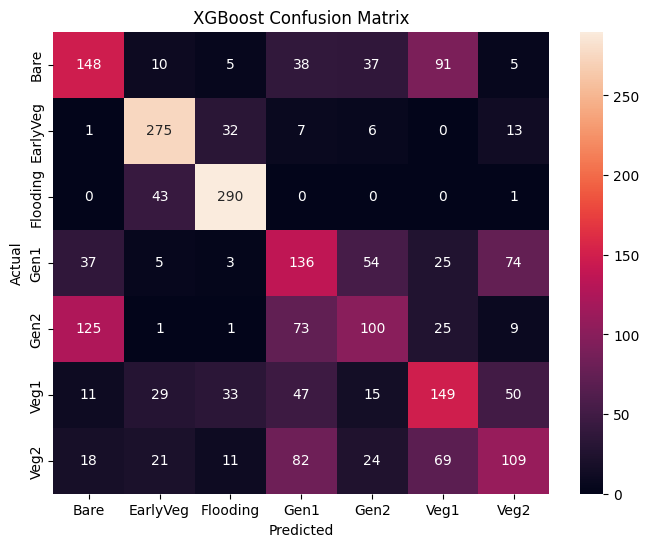

In [ ]:
cm_xgb = confusion_matrix(y_test, pred)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_xgb_df,
    annot=True,
    fmt='d'
)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
imp = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
})

imp = (
    imp.sort_values(
        'Importance',
        ascending=False
    )
)

print(imp.head(20))

       Feature  Importance
14       Month    0.136324
5      VV_Lag1    0.126228
6      VV_Lag2    0.109445
8      VH_Lag2    0.089795
15  S2_Quality    0.074388
7      VH_Lag1    0.068246
1         NDRE    0.057519
10    RVI_Lag2    0.050092
9     RVI_Lag1    0.043236
0         NDVI    0.038512
12    Delta_VH    0.037766
13   Delta_RVI    0.036753
11    Delta_VV    0.034983
3           VH    0.033299
4          RVI    0.032760
2           VV    0.030656


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [200,300,500,700,1000],
    'max_depth': [10,20,30,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_rf,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best RF:")
print(rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF:
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
rf = rf_search.best_estimator_

pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(
    classification_report(
        y_test,
        pred_rf,
        target_names=le.classes_
    )
)

print(
    "\nRF Accuracy =",
    accuracy_score(y_test, pred_rf)
)

              precision    recall  f1-score   support

        Bare       0.43      0.46      0.44       334
    EarlyVeg       0.77      0.78      0.78       334
    Flooding       0.74      0.93      0.82       334
        Gen1       0.36      0.40      0.38       334
        Gen2       0.42      0.29      0.34       334
        Veg1       0.41      0.42      0.41       334
        Veg2       0.38      0.31      0.34       334

    accuracy                           0.51      2338
   macro avg       0.50      0.51      0.50      2338
weighted avg       0.50      0.51      0.50      2338


RF Accuracy = 0.5115483319076134


In [ ]:
imp_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

imp_rf = imp_rf.sort_values(
    'Importance',
    ascending=False
)

print(imp_rf.head(20))

       Feature  Importance
14       Month    0.105995
10    RVI_Lag2    0.088154
8      VH_Lag2    0.083850
1         NDRE    0.075103
6      VV_Lag2    0.073874
5      VV_Lag1    0.073799
9     RVI_Lag1    0.072323
7      VH_Lag1    0.072319
0         NDVI    0.061033
4          RVI    0.049732
3           VH    0.049073
13   Delta_RVI    0.045185
2           VV    0.044896
11    Delta_VV    0.044774
12    Delta_VH    0.043661
15  S2_Quality    0.016230


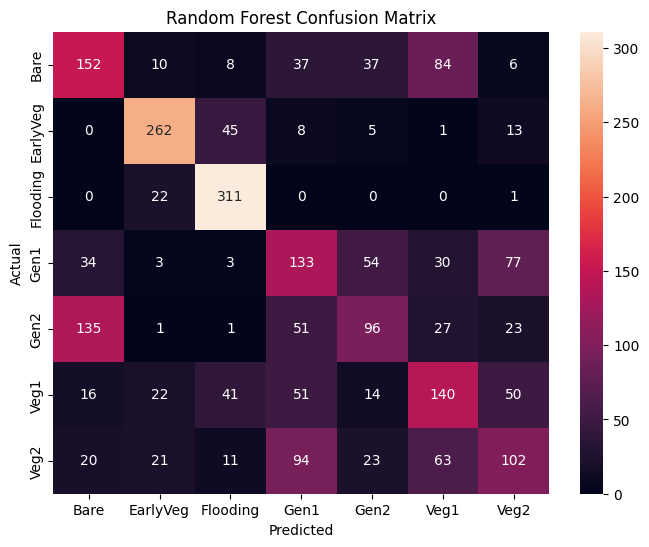

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, pred_rf)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt='d'
)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import joblib

# Random Forest
joblib.dump(
    rf,
    'RF_Final_2020_2024.pkl'
)

# XGBoost
joblib.dump(
    xgb,
    'XGB_Final_2020_2024.pkl'
)

# Label Encoder
joblib.dump(
    le,
    'LabelEncoder_Final.pkl'
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
features = [

    'NDVI',
    'NDRE',

    'VV',
    'VH',
    'RVI',

    'VV_Lag1',
    'VV_Lag2',

    'VH_Lag1',
    'VH_Lag2',

    'RVI_Lag1',
    'RVI_Lag2',

    'Delta_VV',
    'Delta_VH',
    'Delta_RVI',

    'Month',
    'S2_Quality'
]

joblib.dump(
    features,
    'Feature_List.pkl'
)

['Feature_List.pkl']

In [ ]:
from google.colab import files

files.download('RF_Final_2020_2024.pkl')
files.download('XGB_Final_2020_2024.pkl')
files.download('LabelEncoder_Final.pkl')
files.download('Feature_List.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(rf_search.best_score_)
print(xgb_search.best_score_)
print(rf_search.best_params_)
print(xgb_search.best_params_)

0.5849944564815006
0.5921991424746433
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [ ]:
import joblib

joblib.dump(rf_search.best_estimator_, 'RF_Tuned_2021_2024.pkl')
joblib.dump(xgb_search.best_estimator_, 'XGB_Tuned_2021_2024.pkl')
joblib.dump(le, 'LabelEncoder.pkl')

['LabelEncoder.pkl']

In [ ]:
import joblib

joblib.dump(rf_search.best_estimator_, 'RF_Tuned_2021_2024.pkl')
joblib.dump(xgb_search.best_estimator_, 'XGB_Tuned_2021_2024.pkl')
joblib.dump(le, 'LabelEncoder.pkl')

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [ ]:
# ============================================================
# UJI T BERPASANGAN F1-SCORE RANDOM FOREST vs XGBOOST
# ============================================================

from sklearn.metrics import f1_score
from scipy.stats import ttest_rel
import pandas as pd
import numpy as np

# F1-score untuk masing-masing kelas/fase
f1_rf = f1_score(
    y_test,
    pred_rf,
    average=None,
    labels=np.arange(len(le.classes_))
)

f1_xgb = f1_score(
    y_test,
    pred,
    average=None,
    labels=np.arange(len(le.classes_))
)

# Tabel F1-score per fase
f1_table = pd.DataFrame({
    'Fase': le.classes_,
    'F1_RF': f1_rf,
    'F1_XGBoost': f1_xgb
})

print("==============================================")
print("F1-SCORE PER FASE")
print("==============================================")
print(f1_table.round(4))

# ------------------------------------------------------------
# Paired t-test
# ------------------------------------------------------------

t_stat, p_value = ttest_rel(
    f1_rf,
    f1_xgb
)

print("\n==============================================")
print("PAIRED T-TEST")
print("==============================================")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Keputusan   : Tolak H0")
    print("Kesimpulan  : Terdapat perbedaan F1-score yang signifikan")
    print("              antara Random Forest dan XGBoost.")
else:
    print("Keputusan   : Gagal menolak H0")
    print("Kesimpulan  : Tidak terdapat perbedaan F1-score yang signifikan")
    print("              antara Random Forest dan XGBoost.")

F1-SCORE PER FASE
       Fase   F1_RF  F1_XGBoost
0      Bare  0.4399      0.4392
1  EarlyVeg  0.7763      0.7660
2  Flooding  0.8249      0.8181
3      Gen1  0.3757      0.3794
4      Gen2  0.3410      0.3509
5      Veg1  0.4124      0.4300
6      Veg2  0.3366      0.3664

PAIRED T-TEST
t-statistic : -1.1498
p-value     : 0.2940
Keputusan   : Gagal menolak H0
Kesimpulan  : Tidak terdapat perbedaan F1-score yang signifikan
              antara Random Forest dan XGBoost.


F1-SCORE RANDOM FOREST DAN XGBOOST


,Fase,F1_RF,F1_XGBoost
0,Bare,0.4399,0.4392
1,EarlyVeg,0.7763,0.7660
2,Flooding,0.8249,0.8181
3,Gen1,0.3757,0.3794
4,Gen2,0.3410,0.3509
5,Veg1,0.4124,0.4300
6,Veg2,0.3366,0.3664


HASIL PAIRED T-TEST
t-statistic : -1.1498
p-value     : 0.2940
Keputusan   : Gagal menolak H0
Kesimpulan  : Tidak terdapat perbedaan F1-score yang signifikan
              antara Random Forest dan XGBoost.


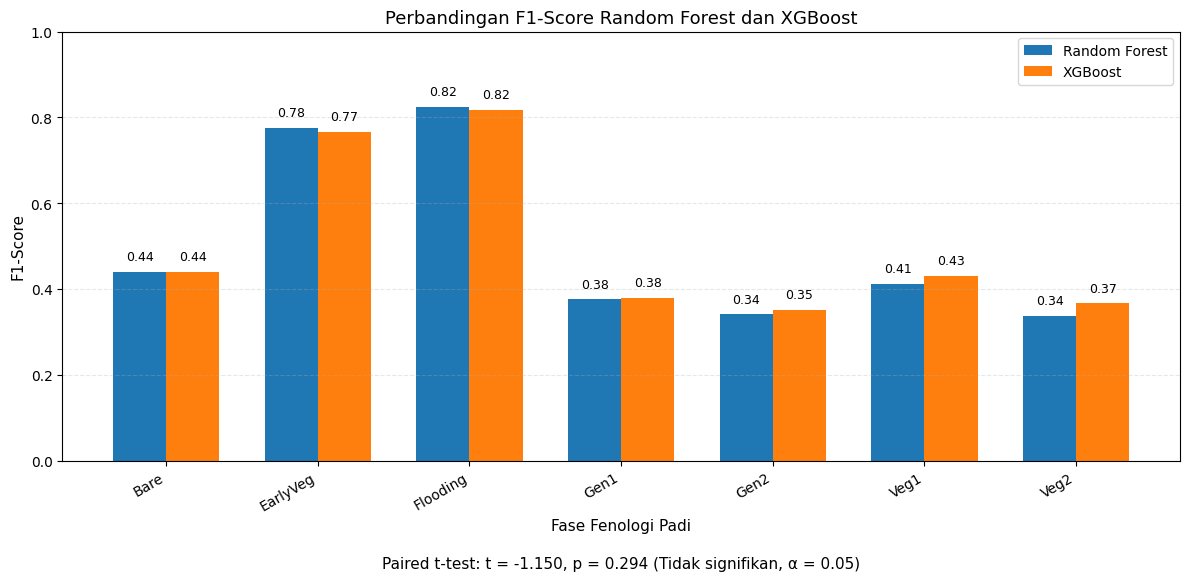

In [ ]:
# ============================================================
# PAIRED T-TEST F1-SCORE RF vs XGBOOST
# + VISUALISASI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from scipy.stats import ttest_rel


# ============================================================
# 1. HITUNG F1-SCORE MASING-MASING FASE
# ============================================================

# Pastikan:
# y_test  = label aktual
# pred_rf = hasil prediksi Random Forest
# pred    = hasil prediksi XGBoost

f1_rf = f1_score(
    y_test,
    pred_rf,
    average=None,
    labels=np.arange(len(le.classes_))
)

f1_xgb = f1_score(
    y_test,
    pred,
    average=None,
    labels=np.arange(len(le.classes_))
)


# ============================================================
# 2. BUAT TABEL F1-SCORE
# ============================================================

f1_table = pd.DataFrame({
    'Fase': le.classes_,
    'F1_RF': f1_rf,
    'F1_XGBoost': f1_xgb
})

print("=" * 60)
print("F1-SCORE RANDOM FOREST DAN XGBOOST")
print("=" * 60)

display(f1_table.round(4))


# ============================================================
# 3. PAIRED T-TEST
# ============================================================

t_stat, p_value = ttest_rel(
    f1_rf,
    f1_xgb
)

print("=" * 60)
print("HASIL PAIRED T-TEST")
print("=" * 60)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Keputusan   : Tolak H0")
    print("Kesimpulan  : Terdapat perbedaan F1-score yang signifikan")
    print("              antara Random Forest dan XGBoost.")
else:
    print("Keputusan   : Gagal menolak H0")
    print("Kesimpulan  : Tidak terdapat perbedaan F1-score yang signifikan")
    print("              antara Random Forest dan XGBoost.")


# ============================================================
# 4. PERSIAPAN VISUALISASI
# ============================================================

fase = f1_table['Fase'].values
rf_scores = f1_table['F1_RF'].values
xgb_scores = f1_table['F1_XGBoost'].values

# Posisi masing-masing fase
x = np.arange(len(fase))

# Lebar batang
width = 0.35


# ============================================================
# 5. VISUALISASI F1-SCORE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

bars_rf = ax.bar(
    x - width / 2,
    rf_scores,
    width,
    label='Random Forest'
)

bars_xgb = ax.bar(
    x + width / 2,
    xgb_scores,
    width,
    label='XGBoost'
)


# ============================================================
# 6. LABEL NILAI F1 DI ATAS BATANG
# ============================================================

for bar in bars_rf:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )


for bar in bars_xgb:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 7. FORMAT GRAFIK
# ============================================================

ax.set_xlabel('Fase Fenologi Padi', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)

ax.set_title(
    'Perbandingan F1-Score Random Forest dan XGBoost',
    fontsize=13
)

ax.set_xticks(x)
ax.set_xticklabels(
    fase,
    rotation=30,
    ha='right'
)

ax.set_ylim(0, 1)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.legend()


# ============================================================
# 8. TAMPILKAN HASIL UJI T PADA GRAFIK
# ============================================================

if p_value < 0.05:
    status = "Signifikan"
else:
    status = "Tidak signifikan"

ax.text(
    0.5,
    -0.25,
    f'Paired t-test: t = {t_stat:.3f}, '
    f'p = {p_value:.3f} ({status}, α = 0.05)',
    transform=ax.transAxes,
    ha='center',
    fontsize=11
)

plt.tight_layout()
plt.show()